# More Incremental Step Test

This page is [adapted from our process control class](https://github.com/ndcbe/controls/blob/main/notebooks/06.02-Simulation-and-Open-Loop-Optimal-Control.ipynb) at Notre Dame; it was developed by Prof. Jeff Kantor.

In [7]:
# Install Pyomo and solvers for Google Colab
import sys

if "google.colab" in sys.modules:
    !wget "https://raw.githubusercontent.com/IDAES/idaes-pse/main/scripts/colab_helper.py"
    import colab_helper

    colab_helper.install_idaes()
    colab_helper.install_ipopt()

# Set plotting defaults
import matplotlib.pyplot as plt

SMALL_SIZE = 14
MEDIUM_SIZE = 16
BIGGER_SIZE = 18

plt.rc('font', size=SMALL_SIZE)  # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)  # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
plt.rc('lines', linewidth=3)

import numpy as np

In this notebook, we will review Pyomo syntax solving optimization problems with our [TCLab model](./tclab_model.ipynb).

Let's start by defining some model coefficients:

In [8]:
# parameters
alpha = 0.00016  # watts / (units P * percent U1)
P = 200  # P units
Ua = 0.050  # heat transfer coefficient from heater to environment
CpH = 2.2  # heat capacity of the heater (J/deg C)
CpS = 1.9  # heat capacity of the sensor (J/deg C)
Ub = 0.021  # heat transfer coefficient from heater to sensor
Tamb = 21.0  # ambient temperature

def step_tests(t)

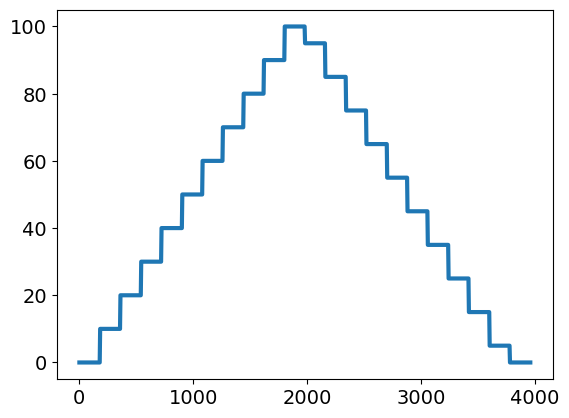

In [9]:
def step_tests(t):
    step_duration = 180 # seconds
    step_size = 10 # percent
    first_group = 11
    for i in range(0, first_group):
        if t < (i+1)*step_duration:
            return i*step_size
    
    for i in range(first_group, 2*first_group - 1):
        if t < (i+1)*step_duration:
            return 95 - (i-first_group)*step_size

    return 0

t_plot = np.linspace(0, 22*180, 1000)
u_plot = [step_tests(t) for t in t_plot]

plt.plot(t_plot, u_plot)


## Simulate a Sequence of Step Tests

We will start by **simulating** our TCLab model. In other words, we will solve the following optimization problem with zero degrees of freedom:

\begin{align*}
\max{}~~ & 0 \\
\mathrm{s.t.}~~ & C_p^H \frac{dT_H}{dt} = U_a (T_{amb} - T_H) + U_b (T_S - T_H) + \alpha P u(t) \\
 & C_p^S \frac{dT_S}{dt} = - U_b (T_S - T_H) \\
 & T_H(t_0) = T_{amb} \\
 & T_S(t_0) = T_{amb} \\
 & u(t) = u_{ramp} = 50\%, \quad \forall t \in [t_0, t_f]
\end{align*}

Here "s.t." means "subject to", i.e., the constraints.

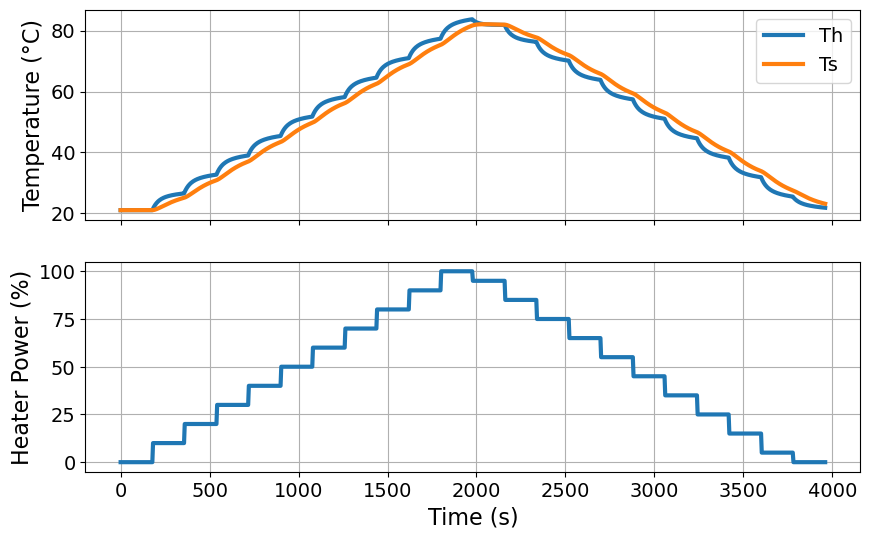

In [10]:
# final time [seconds]
tf = 22*180

# import Pyomo library
import pyomo.environ as pyo
import pyomo.dae as dae

# Create a Pyomo model
m = pyo.ConcreteModel('TCLab Heater/Sensor')

# Define time domain
m.t = dae.ContinuousSet(bounds=(0, tf))

# Define the state variables as a function of time
m.Th = pyo.Var(m.t)
m.Ts = pyo.Var(m.t)

# Define the derivatives of the state variables
m.dTh = dae.DerivativeVar(m.Th)
m.dTs = dae.DerivativeVar(m.Ts)

m.u = pyo.Var(m.t, bounds = (0, 100))

# Define the first differential equation
def heater1(m, t):
    return (
        CpH * m.dTh[t]
        == Ua * (Tamb - m.Th[t]) + Ub * (m.Ts[t] - m.Th[t]) + alpha * P * m.u[t]
    )

m.heater1_con = pyo.Constraint(m.t, rule=heater1)


# Define the second differential equation
def sensor1(m, t):
    return CpS * m.dTs[t] == Ub * (m.Th[t] - m.Ts[t])


m.sensor1_con = pyo.Constraint(m.t, rule=sensor1)

# Set the initial conditions
m.Th[0].fix(Tamb)
m.Ts[0].fix(Tamb)

# Apply a finite difference formula to numerically integrate the differential equations
pyo.TransformationFactory('dae.finite_difference').apply_to(m, nfe=1000, wrt=m.t)

for t in m.t:
    m.u[t].fix(step_tests(t))

# Call our nonlinear optimization/equation solver, Ipopt
pyo.SolverFactory('ipopt').solve(m)

# Plot the results
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Plot 1: Temperature
ax[0].plot(m.t, [m.Th[t]() for t in m.t], label="Th")
ax[0].plot(m.t, [m.Ts[t]() for t in m.t], label="Ts")
ax[0].legend()
ax[0].set_ylabel("Temperature (°C)")
ax[0].grid()

# Plot 2: Heater Power
# ax[1].axhline(u, label="Power")
ax[1].plot(m.t, [m.u[t]() for t in m.t], label="Power")
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Heater Power (%)")
ax[1].grid()

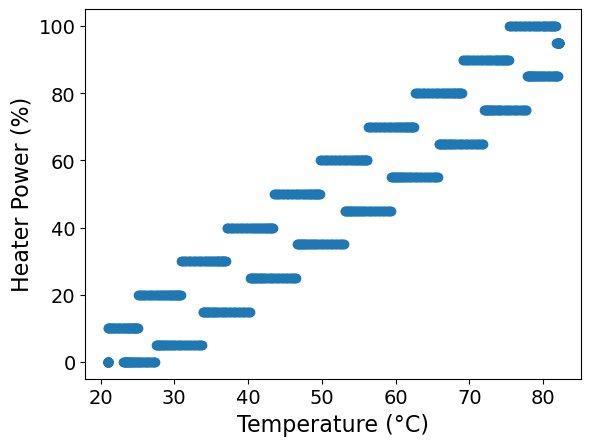

In [11]:
import numpy as np
Ts = np.array([m.Ts[t]() for t in m.t])
u = np.array([m.u[t]() for t in m.t])
plt.xlabel("Temperature (°C)")
plt.ylabel("Heater Power (%)")

plt.scatter(Ts, u)

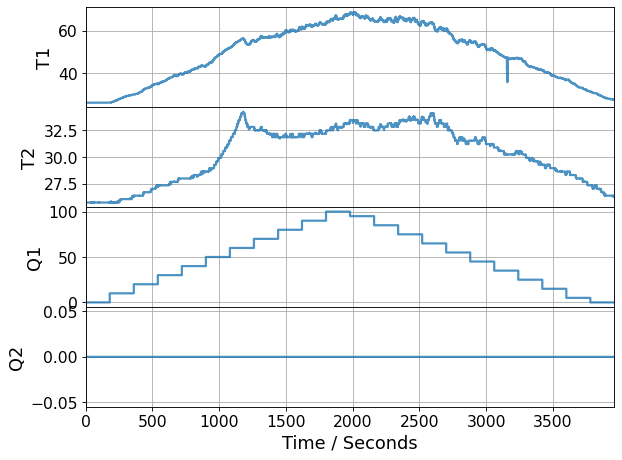

TCLab disconnected successfully.


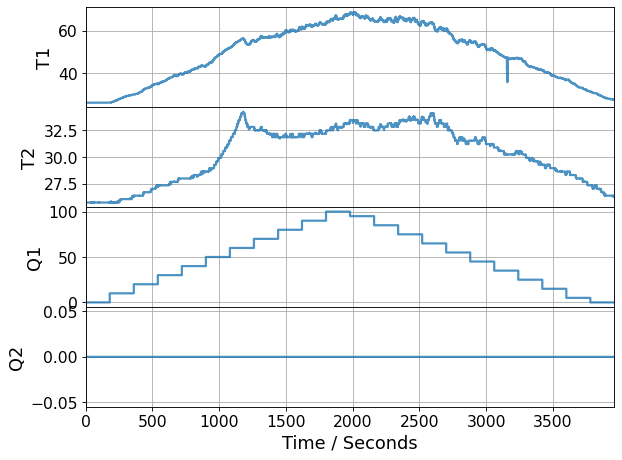

In [12]:
import pandas as pd
from tclab import TCLab, clock, Historian, Plotter

# experimental parameters
P1 = 200
tfinal = tf # seconds, match Pyomo simulation above

# perform experiment
with TCLab() as lab:
    lab.P1 = P1
    h = Historian(lab.sources)
    p = Plotter(h, tfinal)
    lab.Q1(step_tests(0))
    for t in clock(tfinal):
        lab.Q1(step_tests(t))
        p.update(t)

In [13]:
h.to_csv("../data/step_tests2.csv")